In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.collections import LineCollection
from mpl_toolkits.mplot3d import Axes3D

In [2]:
# 3D CIRCULAR RESTRICTED THREE-BODY PROBLEM (CR3BP): Earth-Moon System

# Defining all the variables (arrays) needed to implement this method:

mu = 0.01215058  # Earth-Moon mass ratio used for this analysis

x_Earth = -mu
x_Moon  = 1.0 - mu

dt = 0.0002  # Set the time step

print("3D CIRCULAR RESTRICTED THREE-BODY PROBLEM: Earth-Moon System")
print("" * 60)
print(f"mu = {mu}")
print(f"Earth at ({x_Earth:.6f}, 0, 0)")
print(f"Moon  at ({x_Moon:.6f},  0, 0)")
print(f"State vector (6 components): [x, y, z, v_x, v_y, v_z]")
print(f"dt = {dt}")

3D CIRCULAR RESTRICTED THREE-BODY PROBLEM: Earth-Moon System

mu = 0.01215058
Earth at (-0.012151, 0, 0)
Moon  at (0.987849,  0, 0)
State vector (6 components): [x, y, z, v_x, v_y, v_z]
dt = 0.0002


In [3]:
# Set the necessary boundary conditions:

# 3D EQUATIONS OF MOTION

def eff_potential(x, y, z):
    """
    Ω(x,y,z) = 0.5*(x^2 + y^2) + (1-μ)/r1 + μ/r2
    Note: z does NOT appear in the centrifugal term (only x,y).
    """
    r1 = np.sqrt((x - x_Earth)**2 + y**2 + z**2)
    r2 = np.sqrt((x - x_Moon)**2 + y**2 + z**2)
    return 0.5 * (x**2 + y**2) + (1 - mu) / r1 + mu / r2


def eom(state):
    """
    3D CR3BP equations in the rotating frame.
    
    Input:  state = [x, y, z, vx, vy, vz]
    Output: [dx/dt, dy/dt, dz/dt, dvx/dt, dvy/dt, dvz/dt]
    
    x'' =  2*vy + x - (1-μ)*(x+μ)/r1^3 - μ*(x-1+μ)/r2^3
    y'' = -2*vx + y - (1-μ)*y/r1^3       - μ*y/r2^3
    z'' =           - (1-μ)*z/r1^3        - μ*z/r2^3
    
    The z-equation has NO Coriolis (2v) or centrifugal (+z) terms
    because the rotation axis is parallel to z.
    """
    x, y, z, vx, vy, vz = state
    
    r1 = np.sqrt((x - x_Earth)**2 + y**2 + z**2)
    r2 = np.sqrt((x - x_Moon)**2 + y**2 + z**2)
    r1 = max(r1, 1e-12)
    r2 = max(r2, 1e-12)
    
    # x-acceleration: Coriolis + centrifugal + gravity
    ax = (2.0*vy + x
          - (1-mu)*(x - x_Earth)/r1**3
          - mu*(x - x_Moon)/r2**3)
    
    # y-acceleration: Coriolis + centrifugal + gravity
    ay = (-2.0*vx + y
          - (1-mu)*y/r1**3
          - mu*y/r2**3)
    
    # z-acceleration: gravity ONLY (no Coriolis, no centrifugal)
    az = (-(1-mu)*z/r1**3
          - mu*z/r2**3)
    
    return np.array([vx, vy, vz, ax, ay, az])


def jacobi(state):
    """CJ = 2*Ω - v^2 (now includes vz)."""
    x, y, z, vx, vy, vz = state
    omega = eff_potential(x, y, z)
    return 2.0 * omega - (vx**2 + vy**2 + vz**2)


# LAGRANGE POINTS

def find_lagrange(mu, x0, tol=1e-14):
    x = x0
    for _ in range(500):
        r1 = abs(x - x_Earth); r2 = abs(x - x_Moon)
        f = x - (1-mu)*(x-x_Earth)/r1**3 - mu*(x-x_Moon)/r2**3
        df = 1 + 2*(1-mu)/r1**3 + 2*mu/r2**3
        xn = x - f/df
        if abs(xn - x) < tol: return xn
        x = xn
    return x

L1 = find_lagrange(mu, 0.8)
L2 = find_lagrange(mu, 1.15)
print(f"L1 = {L1:.8f}")
print(f"L2 = {L2:.8f}")


# INITIAL CONDITIONS: Define the 4 orbit types

# A: Planar retrograde orbit around Earth (z=0 throughout)
state_A = np.array([0.4, 0.0, 0.0, 0.0, -1.2, 0.0])
n_A = 300000

# B: Planar transfer orbit (z=0 throughout)
state_B = np.array([0.4, 0.0, 0.0, 0.0, 1.05, 0.0])
n_B = 200000

# C: 3D halo-like orbit near L1
# Start slightly above the orbital plane with vy to create out-of-plane motion
state_C = np.array([L1 - 0.02, 0.0, 0.04, 0.0, -0.15, 0.0])
n_C = 250000

# D: 3D orbit near Moon with z-oscillation
state_D = np.array([0.92, 0.0, 0.03, 0.0, 0.5, 0.05])
n_D = 250000

print("\nInitial conditions:")
print(f"  A (planar retrograde):  {state_A}")
print(f"  B (planar transfer):    {state_B}")
print(f"  C (3D near L1):         {state_C}")
print(f"  D (3D near Moon):       {state_D}")

L1 = 0.83691515
L2 = 1.15568214

Initial conditions:
  A (planar retrograde):  [ 0.4  0.   0.   0.  -1.2  0. ]
  B (planar transfer):    [0.4  0.   0.   0.   1.05 0.  ]
  C (3D near L1):         [ 0.81691515  0.          0.04        0.         -0.15        0.        ]
  D (3D near Moon):       [0.92 0.   0.03 0.   0.5  0.05]


In [4]:
# Implementing and solving using a numerical method

# CLASSICAL 4TH-ORDER RUNGE-KUTTA (RK4)

# System: du/dt = f(u), where u = [x, y, z, vx, vy, vz]

#   k1 = f(u^n)
#   k2 = f(u^n + dt/2 * k1)
#   k3 = f(u^n + dt/2 * k2)
#   k4 = f(u^n + dt * k3)
#   u^(n+1) = u^n + (dt/6)(k1 + 2*k2 + 2*k3 + k4)


def rk4_step(state, dt):
    k1 = eom(state)
    k2 = eom(state + 0.5*dt*k1)
    k3 = eom(state + 0.5*dt*k2)
    k4 = eom(state + dt*k3)
    return state + (dt/6.0)*(k1 + 2*k2 + 2*k3 + k4)


def integrate(state0, dt, n_steps):
    traj = np.zeros((n_steps + 1, 6))
    traj[0] = state0
    for i in range(n_steps):
        traj[i+1] = rk4_step(traj[i], dt)
    time = np.arange(n_steps + 1) * dt
    return traj, time


# Integrate all four orbits
print("Integrating Orbit A (planar retrograde)...")
traj_A, time_A = integrate(state_A, dt, n_A)
print(f"  Done. z_max = {np.max(np.abs(traj_A[:,2])):.2e} (should be ~0)")

print("Integrating Orbit B (planar transfer)...")
traj_B, time_B = integrate(state_B, dt, n_B)
print(f"  Done. z_max = {np.max(np.abs(traj_B[:,2])):.2e} (should be ~0)")

print("Integrating Orbit C (3D near L1)...")
traj_C, time_C = integrate(state_C, dt, n_C)
print(f"  Done. z range = [{np.min(traj_C[:,2]):.4f}, {np.max(traj_C[:,2]):.4f}]")

print("Integrating Orbit D (3D near Moon)...")
traj_D, time_D = integrate(state_D, dt, n_D)
print(f"  Done. z range = [{np.min(traj_D[:,2]):.4f}, {np.max(traj_D[:,2]):.4f}]")

# Validate: Jacobi constant conservation
print("\nJacobi constant validation:")
for label, traj in [("A (planar retro)", traj_A), ("B (planar trans)", traj_B),
                     ("C (3D L1)", traj_C), ("D (3D Moon)", traj_D)]:
    CJ = np.array([jacobi(traj[i]) for i in range(0, len(traj), 100)])
    err = np.max(np.abs(CJ - CJ[0]) / np.abs(CJ[0]))
    print(f"  {label}: CJ_0 = {CJ[0]:.6f}, max rel error = {err:.2e}")

Integrating Orbit A (planar retrograde)...
  Done. z_max = 0.00e+00 (should be ~0)
Integrating Orbit B (planar transfer)...
  Done. z_max = 0.00e+00 (should be ~0)
Integrating Orbit C (3D near L1)...
  Done. z range = [-0.0462, 0.0483]
Integrating Orbit D (3D near Moon)...
  Done. z range = [-0.0377, 0.0376]

Jacobi constant validation:
  A (planar retro): CJ_0 = 3.554973, max rel error = 1.71e-08
  B (planar trans): CJ_0 = 3.892473, max rel error = 2.21e-14
  C (3D L1): CJ_0 = 3.163551, max rel error = 1.15e-11
  D (3D Moon): CJ_0 = 3.039881, max rel error = 1.90e-14


In [5]:
# Conducting post-processing steps

# POST-PROCESSING

# 1. Zero-velocity surface field (in the z=0 plane)
xg = np.linspace(-1.5, 1.5, 800)
yg = np.linspace(-1.5, 1.5, 800)
X, Y = np.meshgrid(xg, yg)
R1 = np.sqrt((X - x_Earth)**2 + Y**2)
R2 = np.sqrt((X - x_Moon)**2 + Y**2)
CJ_field = (X**2 + Y**2) + 2*(1-mu)/R1 + 2*mu/R2


# 2. Poincare section (z=0 crossings, vz>0 for 3D orbits)
def poincare_z(traj):
    """Find z=0 crossings with vz>0 for 3D orbits."""
    cx, cy = [], []
    for i in range(len(traj)-1):
        if traj[i,2]*traj[i+1,2] < 0 and traj[i+1,5] > 0:
            f = -traj[i,2]/(traj[i+1,2]-traj[i,2])
            cx.append(traj[i,0]+f*(traj[i+1,0]-traj[i,0]))
            cy.append(traj[i,1]+f*(traj[i+1,1]-traj[i,1]))
    return np.array(cx), np.array(cy)

def poincare_y(traj):
    """Find y=0 crossings with vy>0 for planar orbits."""
    cx, cvx = [], []
    for i in range(len(traj)-1):
        if traj[i,1]*traj[i+1,1] < 0 and traj[i+1,4] > 0:
            f = -traj[i,1]/(traj[i+1,1]-traj[i,1])
            cx.append(traj[i,0]+f*(traj[i+1,0]-traj[i,0]))
            cvx.append(traj[i,3]+f*(traj[i+1,3]-traj[i,3]))
    return np.array(cx), np.array(cvx)

poinc_A_x, poinc_A_vx = poincare_y(traj_A)
poinc_B_x, poinc_B_vx = poincare_y(traj_B)
poinc_C_x, poinc_C_y  = poincare_z(traj_C)
poinc_D_x, poinc_D_y  = poincare_z(traj_D)

print(f"Poincare crossings: A={len(poinc_A_x)}, B={len(poinc_B_x)}, C={len(poinc_C_x)}, D={len(poinc_D_x)}")


# 3. Jacobi constant time series
vs = 200
CJ_series = {}
t_series = {}
for label, traj, tarr in [("A", traj_A, time_A), ("B", traj_B, time_B),
                           ("C", traj_C, time_C), ("D", traj_D, time_D)]:
    CJ_series[label] = np.array([jacobi(traj[i]) for i in range(0, len(traj), vs)])
    t_series[label] = tarr[::vs]


# 4. ADDITIONAL TOPIC: Fourier analysis
def fft_func(signal, dt):
    sig = signal - np.mean(signal)
    N = len(sig)
    w = np.hanning(N)
    fv = np.fft.fft(sig * w)
    fr = np.fft.fftfreq(N, d=dt)
    pos = fr > 0
    return fr[pos], np.abs(fv[pos])**2

def get_peaks(freqs, power, max_f=15, n=5):
    m = freqs < max_f
    f, p = freqs[m], power[m]
    peaks = [(f[i], p[i]) for i in range(1, len(p)-1) if p[i]>p[i-1] and p[i]>p[i+1]]
    peaks.sort(key=lambda x: x[1], reverse=True)
    return peaks[:n]

# FFT of x(t), y(t), z(t) for the 3D orbits
fft_data = {}
for label, traj in [("C", traj_C), ("D", traj_D)]:
    fft_data[label] = {}
    for comp, name in [(0, 'x'), (1, 'y'), (2, 'z')]:
        fr, pw = fft_func(traj[:, comp], dt)
        pk = get_peaks(fr, pw)
        fft_data[label][name] = (fr, pw, pk)

print("\nDominant z-frequencies (Orbit C, 3D L1):")
for f, p in fft_data["C"]["z"][2][:3]:
    print(f"  f = {f:.3f}, T = {1/f:.3f}")

print("\nPost-processing complete.")

Poincare crossings: A=92, B=21, C=23, D=36

Dominant z-frequencies (Orbit C, 3D L1):
  f = 0.520, T = 1.923
  f = 0.460, T = 2.174
  f = 1.040, T = 0.962

Post-processing complete.


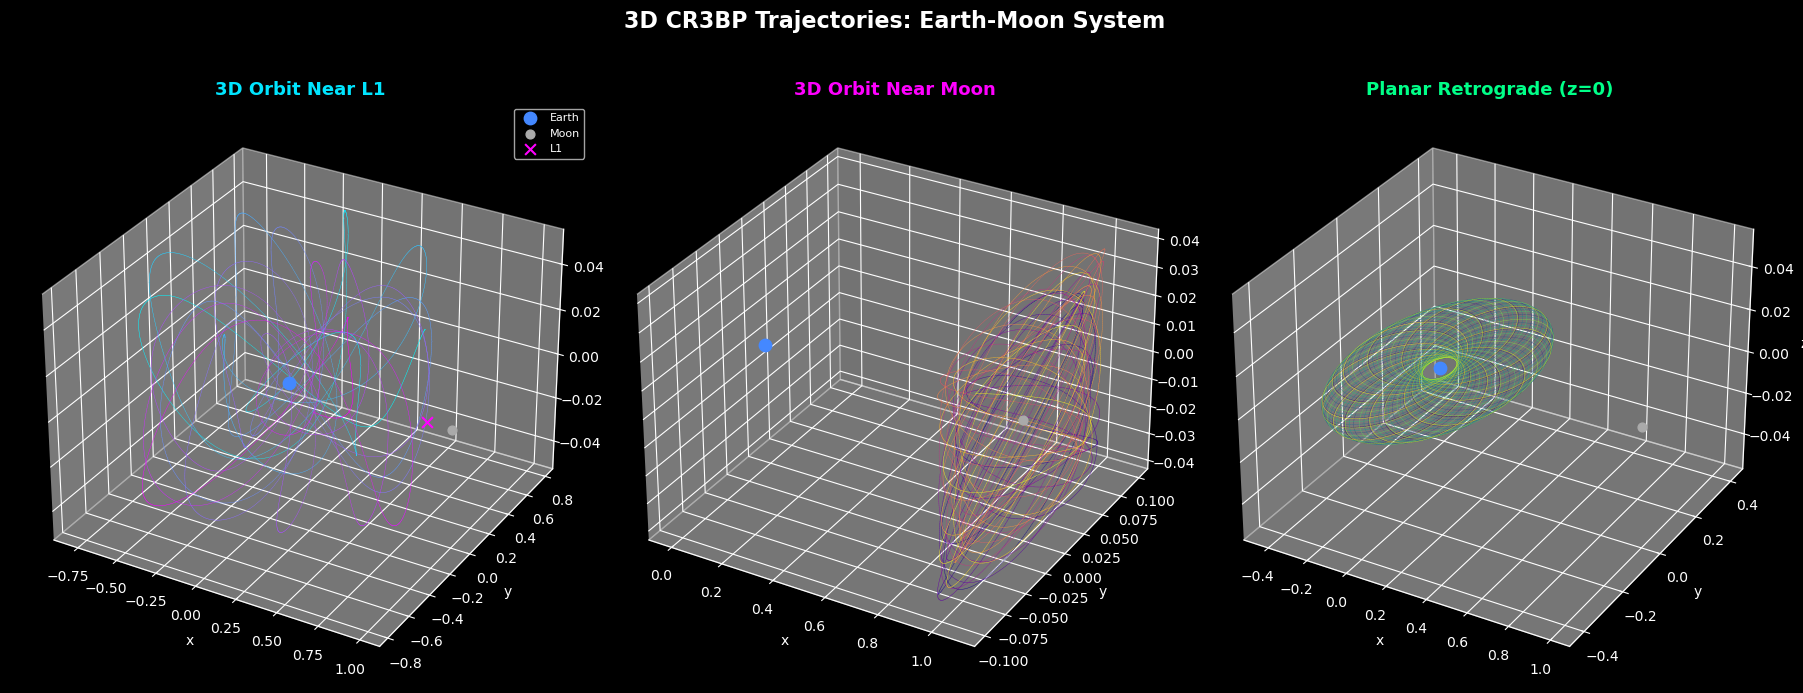

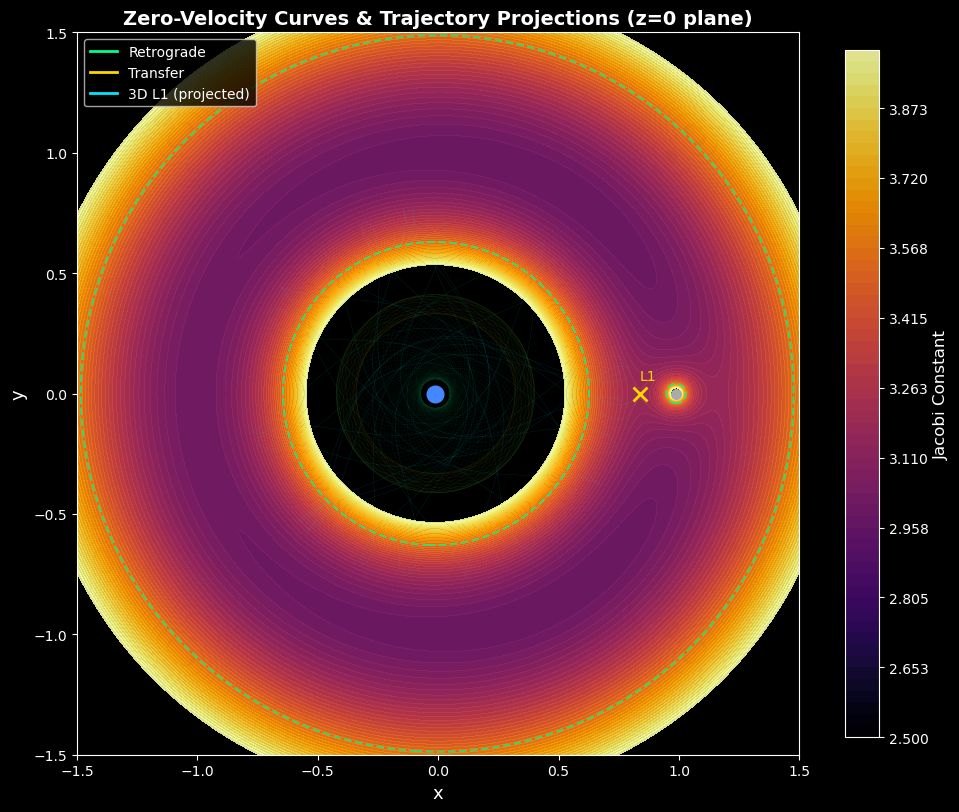

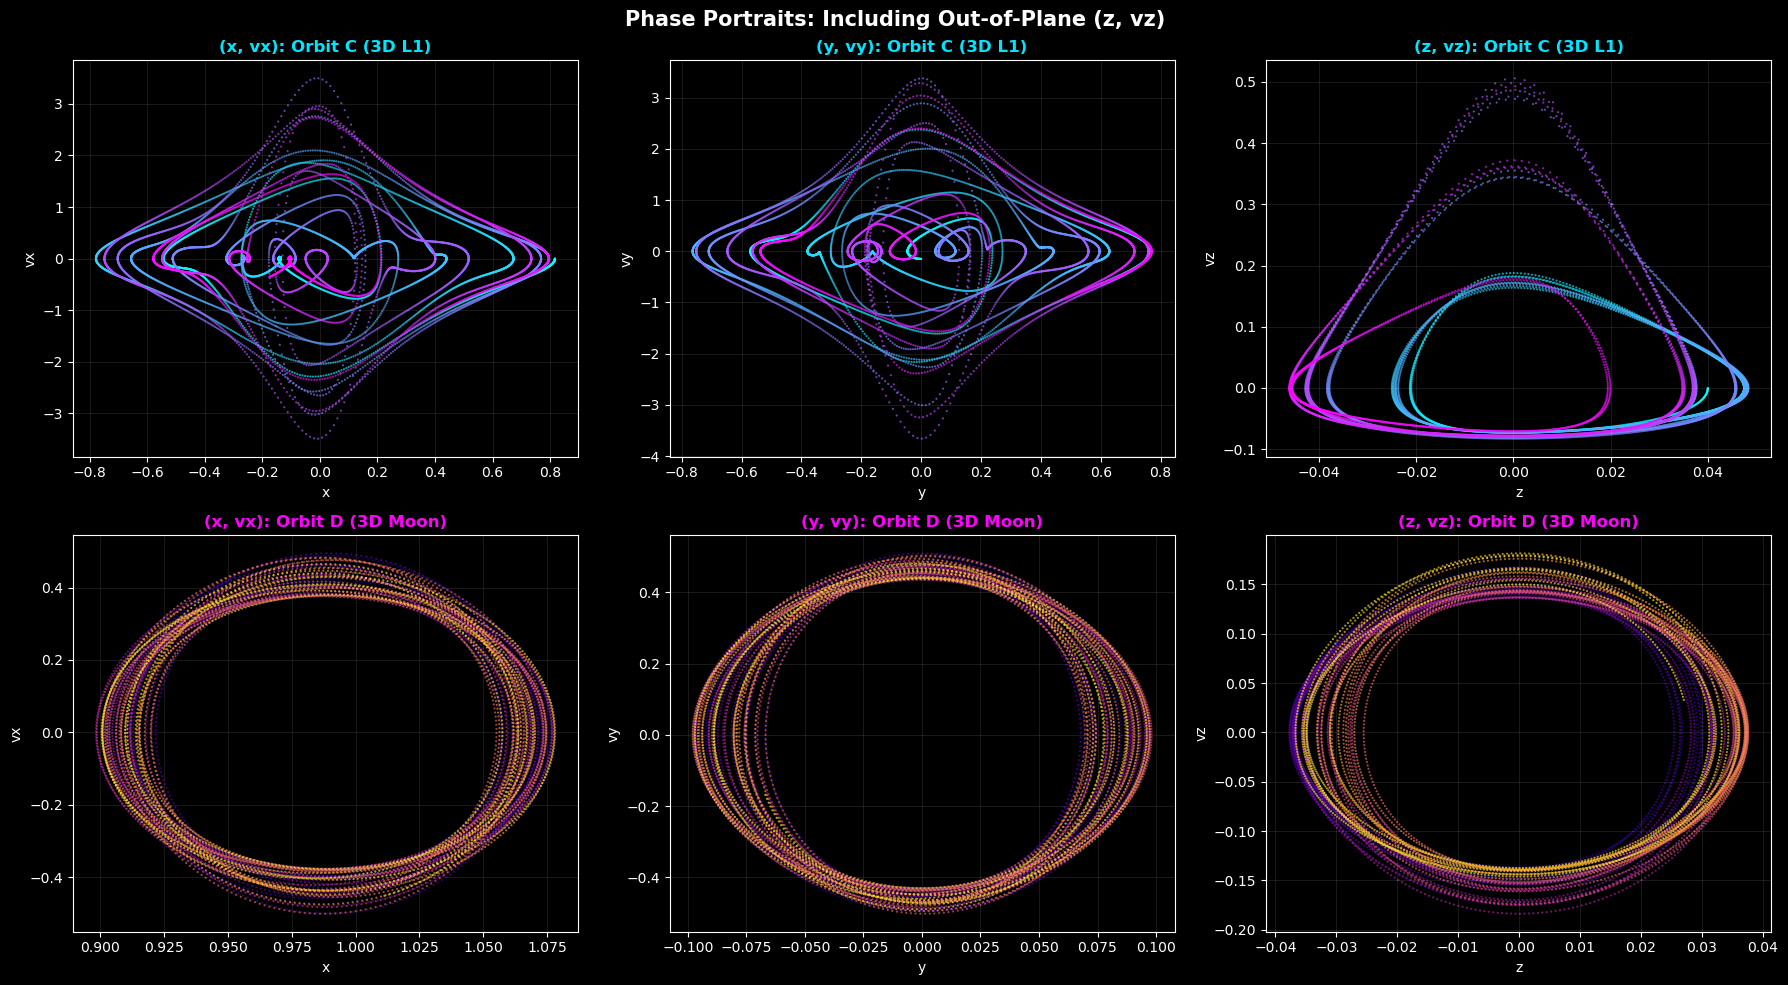

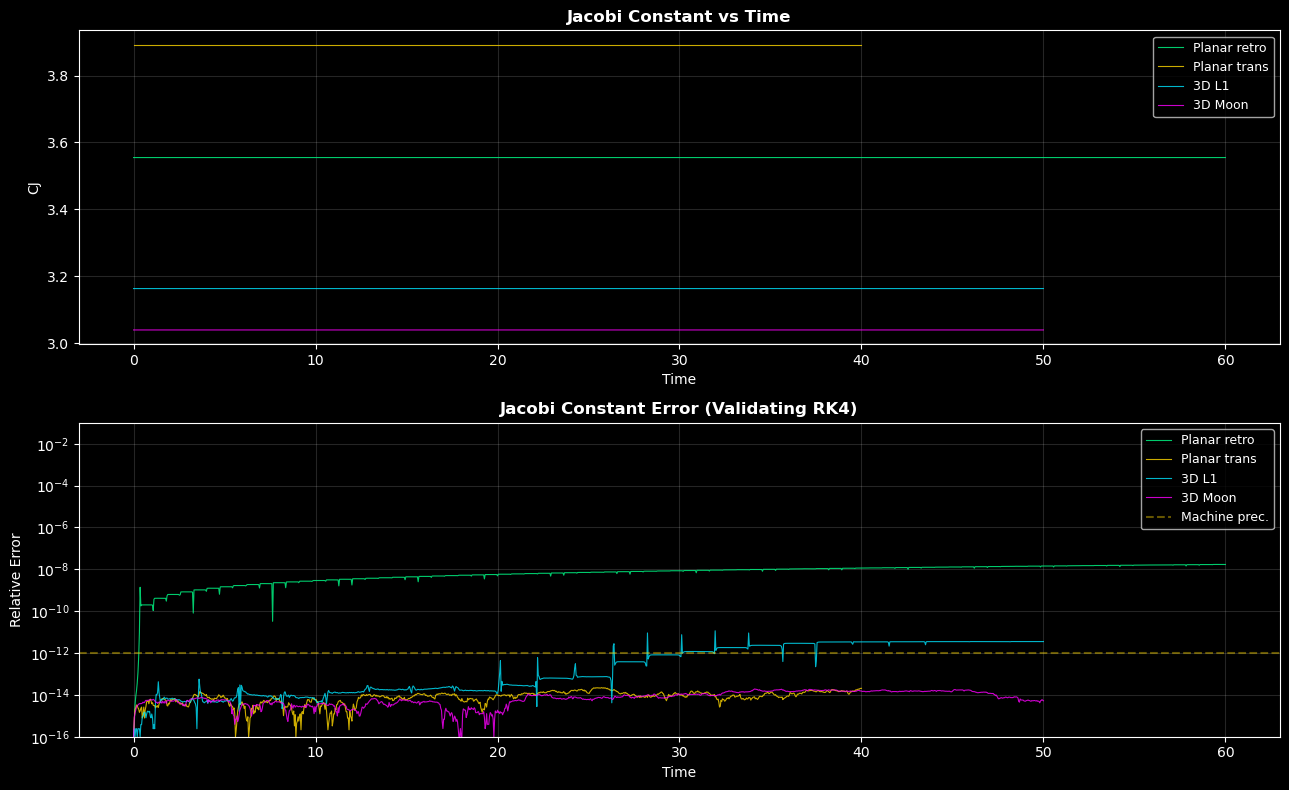

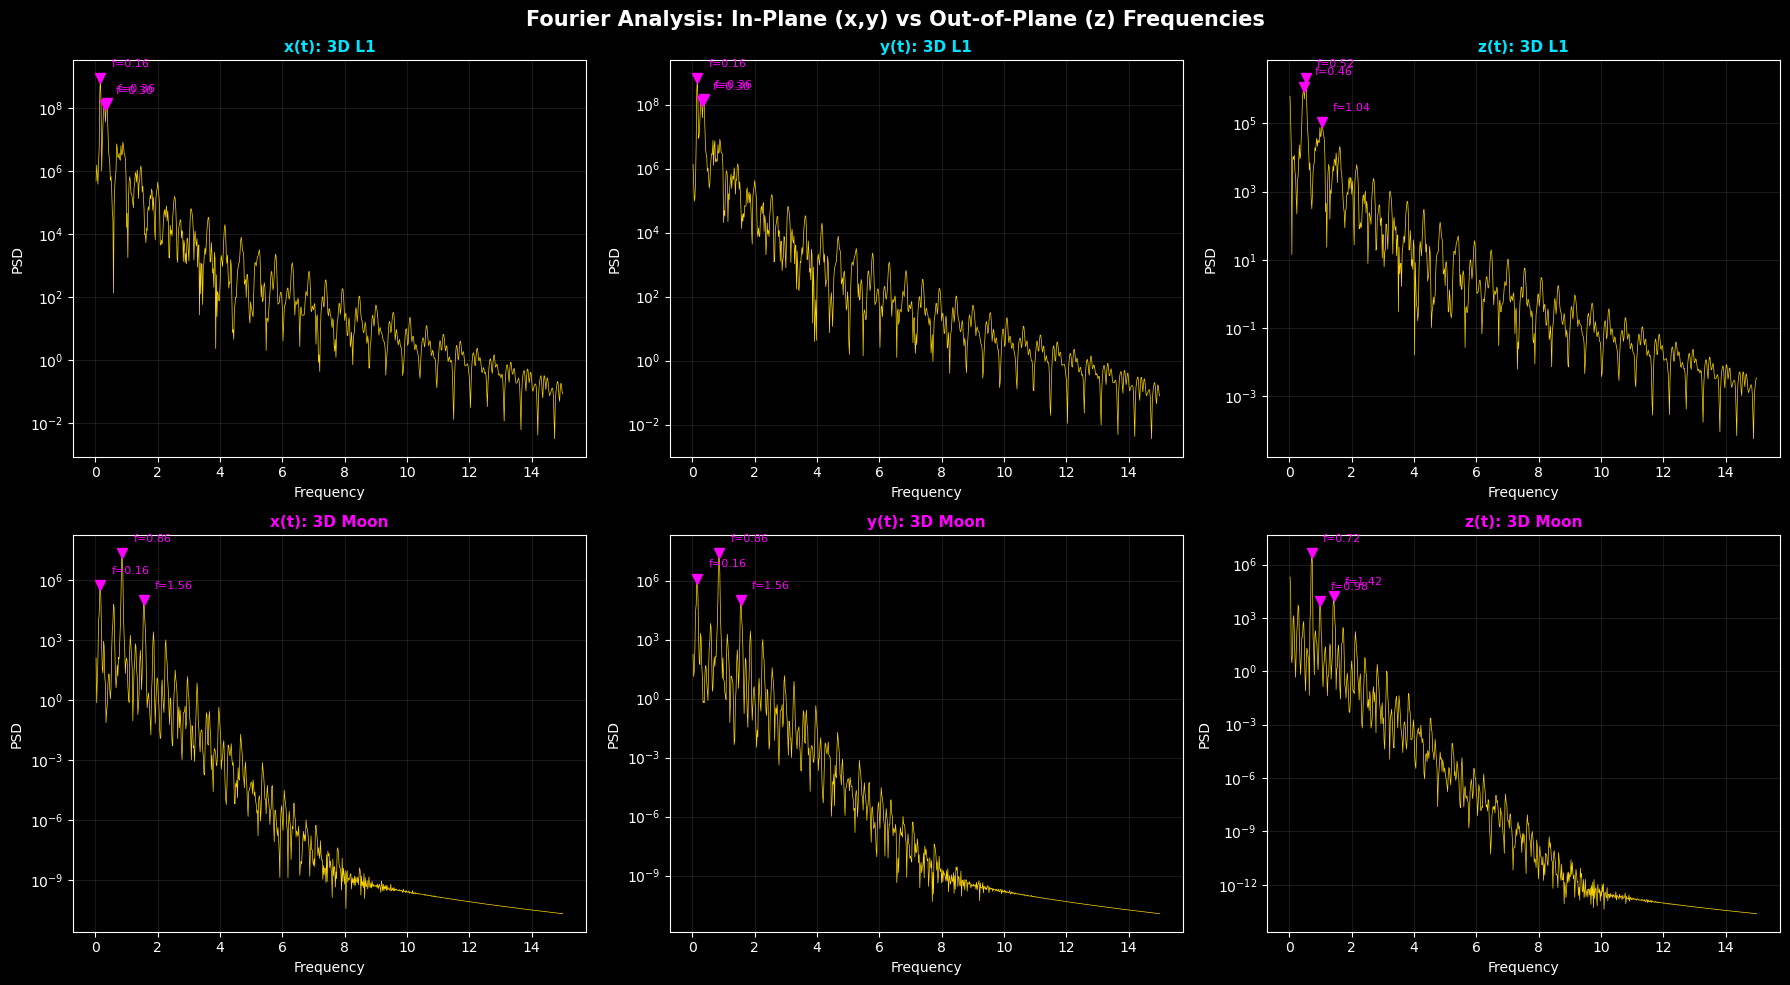

In [6]:
# Plotting the final obtained results

plt.style.use('dark_background')
CYAN='#00E5FF'; GREEN='#00FF88'; MAGENTA='#FF00FF'; GOLD='#FFD700'
ORANGE='#FF6B35'; BLUE='#4488FF'; GREY='#AAAAAA'; RED='#FF4444'


# FIGURE 1: 3D trajectory plots
fig = plt.figure(figsize=(18, 7))

# Orbit C: 3D near L1
ax = fig.add_subplot(131, projection='3d')
n = len(traj_C)
colors = cm.cool(np.linspace(0, 1, n))
for i in range(0, n-1, 20):
    ax.plot(traj_C[i:i+21, 0], traj_C[i:i+21, 1], traj_C[i:i+21, 2],
            color=colors[i], linewidth=0.3, alpha=0.8)
ax.scatter([x_Earth], [0], [0], color=BLUE, s=80, zorder=10, label='Earth')
ax.scatter([x_Moon], [0], [0], color=GREY, s=40, zorder=10, label='Moon')
ax.scatter([L1], [0], [0], color=MAGENTA, s=60, marker='x', zorder=10, label='L1')
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
ax.set_title('3D Orbit Near L1', fontsize=13, fontweight='bold', color=CYAN)
ax.legend(fontsize=8)

# Orbit D: 3D near Moon
ax = fig.add_subplot(132, projection='3d')
colors2 = cm.plasma(np.linspace(0, 1, len(traj_D)))
for i in range(0, len(traj_D)-1, 20):
    ax.plot(traj_D[i:i+21, 0], traj_D[i:i+21, 1], traj_D[i:i+21, 2],
            color=colors2[i], linewidth=0.3, alpha=0.8)
ax.scatter([x_Earth], [0], [0], color=BLUE, s=80, zorder=10)
ax.scatter([x_Moon], [0], [0], color=GREY, s=40, zorder=10)
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
ax.set_title('3D Orbit Near Moon', fontsize=13, fontweight='bold', color=MAGENTA)

# Planar orbit A for comparison
ax = fig.add_subplot(133, projection='3d')
colors3 = cm.viridis(np.linspace(0, 1, len(traj_A)))
for i in range(0, len(traj_A)-1, 30):
    ax.plot(traj_A[i:i+31, 0], traj_A[i:i+31, 1], traj_A[i:i+31, 2],
            color=colors3[i], linewidth=0.3, alpha=0.8)
ax.scatter([x_Earth], [0], [0], color=BLUE, s=80, zorder=10)
ax.scatter([x_Moon], [0], [0], color=GREY, s=40, zorder=10)
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
ax.set_title('Planar Retrograde (z=0)', fontsize=13, fontweight='bold', color=GREEN)

plt.suptitle('3D CR3BP Trajectories: Earth-Moon System', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


# FIGURE 4: Zero-velocity curves + planar trajectories overlay
fig, ax = plt.subplots(figsize=(10, 9))

levels = np.linspace(2.5, 4.0, 60)
cf = ax.contourf(X, Y, CJ_field, levels=levels, cmap='inferno', alpha=0.9)

CJ_A = jacobi(state_A)
ax.contour(X, Y, CJ_field, levels=[CJ_A], colors=[GREEN], linewidths=1.5, linestyles='--', alpha=0.7)

ax.plot(traj_A[:, 0], traj_A[:, 1], color=GREEN, alpha=0.2, linewidth=0.1, label='Retrograde')
ax.plot(traj_B[:, 0], traj_B[:, 1], color=GOLD, alpha=0.2, linewidth=0.1, label='Transfer')
ax.plot(traj_C[:, 0], traj_C[:, 1], color=CYAN, alpha=0.3, linewidth=0.15, label='3D L1 (projected)')

ax.plot(x_Earth, 0, 'o', color=BLUE, markersize=12, zorder=10)
ax.plot(x_Moon, 0, 'o', color=GREY, markersize=7, zorder=10)
ax.plot(L1, 0, 'x', color=GOLD, markersize=10, markeredgewidth=2, zorder=10)
ax.annotate('L1', (L1, 0), textcoords='offset points', xytext=(0,10), color=GOLD, fontsize=10)

cbar = plt.colorbar(cf, ax=ax, shrink=0.8)
cbar.set_label('Jacobi Constant', fontsize=12)
ax.set_xlabel('x', fontsize=13); ax.set_ylabel('y', fontsize=13)
ax.set_title('Zero-Velocity Curves & Trajectory Projections (z=0 plane)', fontsize=14, fontweight='bold')
ax.set_aspect('equal'); ax.set_xlim([-1.5, 1.5]); ax.set_ylim([-1.5, 1.5])
ax.legend(fontsize=10, loc='upper left')
leg = ax.legend(fontsize=10, loc='upper left')
for line in leg.get_lines():
    line.set_alpha(1.0)
    line.set_linewidth(2.0)
plt.tight_layout()
plt.show()


# FIGURE 5: Phase portraits: including z vs vz
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for row, (traj, label, col, cmap_name) in enumerate([
    (traj_C, 'Orbit C (3D L1)', CYAN, 'cool'),
    (traj_D, 'Orbit D (3D Moon)', MAGENTA, 'plasma'),
]):
    s = 20
    nc = len(traj[::s])
    c = getattr(cm, cmap_name)(np.linspace(0, 1, nc))
    
    axes[row,0].scatter(traj[::s,0], traj[::s,3], c=c, s=0.3, alpha=0.7)
    axes[row,0].set_xlabel('x'); axes[row,0].set_ylabel('vx')
    axes[row,0].set_title(f'(x, vx): {label}', fontweight='bold', color=col)
    axes[row,0].grid(True, alpha=0.1)
    
    axes[row,1].scatter(traj[::s,1], traj[::s,4], c=c, s=0.3, alpha=0.7)
    axes[row,1].set_xlabel('y'); axes[row,1].set_ylabel('vy')
    axes[row,1].set_title(f'(y, vy): {label}', fontweight='bold', color=col)
    axes[row,1].grid(True, alpha=0.1)
    
    # NEW: z vs vz phase portrait
    axes[row,2].scatter(traj[::s,2], traj[::s,5], c=c, s=0.3, alpha=0.7)
    axes[row,2].set_xlabel('z'); axes[row,2].set_ylabel('vz')
    axes[row,2].set_title(f'(z, vz): {label}', fontweight='bold', color=col)
    axes[row,2].grid(True, alpha=0.1)

plt.suptitle('Phase Portraits: Including Out-of-Plane (z, vz)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


# FIGURE 7: Jacobi constant conservation
fig, axes = plt.subplots(2, 1, figsize=(13, 8))

plot_data = [("A", GREEN, 'Planar retro'), ("B", GOLD, 'Planar trans'),
             ("C", CYAN, '3D L1'), ("D", MAGENTA, '3D Moon')]

for key, col, lab in plot_data:
    axes[0].plot(t_series[key], CJ_series[key], color=col, linewidth=0.8, alpha=0.8, label=lab)
axes[0].set_xlabel('Time'); axes[0].set_ylabel('CJ')
axes[0].set_title('Jacobi Constant vs Time', fontweight='bold'); axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.15)

for key, col, lab in plot_data:
    err = np.abs(CJ_series[key] - CJ_series[key][0]) / np.abs(CJ_series[key][0])
    axes[1].semilogy(t_series[key], err + 1e-16, color=col, linewidth=0.8, alpha=0.8, label=lab)
axes[1].axhline(y=1e-12, color=GOLD, linestyle='--', alpha=0.4, label='Machine prec.')
axes[1].set_xlabel('Time'); axes[1].set_ylabel('Relative Error')
axes[1].set_title('Jacobi Constant Error (Validating RK4)', fontweight='bold')
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.15)
axes[1].set_ylim([1e-16, 1e-1])

plt.tight_layout()
plt.show()


# FIGURE 8: Fourier analysis: x, y, z spectra compared (additional topic chosen from ME2 MCP)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for row, (label, col) in enumerate([("C", CYAN), ("D", MAGENTA)]):
    traj = traj_C if label=="C" else traj_D
    tarr = time_C if label=="C" else time_D
    orbit_name = '3D L1' if label=="C" else '3D Moon'
    
    for col_idx, (comp, comp_name) in enumerate([(0,'x'), (1,'y'), (2,'z')]):
        ax = axes[row, col_idx]
        fr, pw, pk = fft_data[label][comp_name]
        
        fm = fr < 15
        ax.semilogy(fr[fm], pw[fm], color=GOLD, linewidth=0.5)
        
        for f_pk, p_pk in pk[:3]:
            ax.plot(f_pk, p_pk, 'v', color=MAGENTA, markersize=7)
            ax.annotate(f'f={f_pk:.2f}', (f_pk, p_pk), textcoords='offset points',
                        xytext=(8, 8), color=MAGENTA, fontsize=8)
        
        ax.set_xlabel('Frequency', fontsize=10)
        ax.set_ylabel('PSD', fontsize=10)
        ax.set_title(f'{comp_name}(t): {orbit_name}', fontsize=11, fontweight='bold', color=col)
        ax.grid(True, alpha=0.1)

plt.suptitle('Fourier Analysis: In-Plane (x,y) vs Out-of-Plane (z) Frequencies', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [8]:
# In this section we are celebrating
print('CW done: We deserve a good mark')

CW done: We deserve a good mark
